<a href="https://colab.research.google.com/github/Pavanreddy114/Sales_Demand_Forecasting_ML_Task1/blob/main/Sales_Demand_Forecasting_ML_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving sales_dataset.xlsx to sales_dataset.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
file_name = list(uploaded.keys())[0]

# Row 7 → header=6
df = pd.read_excel(
    file_name,
    header=7
)

df.head()

,Unnamed: 0,Order No,Order Date,Customer Name,Ship Date,Retail Price (USD),Order Quantity,Tax (USD),Total (USD)
0,NaN,1001,2024-01-01,John Smith,2024-01-03,49.99,2,9.998,109.978
1,NaN,1002,2024-01-01,Jane Doe,2024-01-04,29.99,1,2.999,32.989
2,NaN,1003,2024-01-02,Michael Johnson,2024-01-07,99.99,3,29.997,329.967
3,NaN,1004,2024-01-02,Emily Brown,2024-01-03,19.99,4,7.996,87.956
4,NaN,1005,2024-01-03,David Wilson,2024-01-08,149.99,1,14.999,164.989


In [ ]:
df = df.dropna(axis=1, how='all')

df.head()
print(df.columns)

Index(['Order No', 'Order Date', 'Customer Name', 'Ship Date',
       'Retail Price (USD)', 'Order Quantity', 'Tax (USD)', 'Total (USD)'],
      dtype='object')


In [ ]:
df['Order Date'] = pd.to_datetime(
    df['Order Date']
)

df['Total (USD)'] = pd.to_numeric(
    df['Total (USD)']
)

df['Order Quantity'] = pd.to_numeric(
    df['Order Quantity']
)

In [ ]:
sales = (
    df.groupby(
        'Order Date'
    )['Total (USD)']
    .sum()
    .reset_index()
)

sales.head()

,Order Date,Total (USD)
0,2024-01-01,142.967
1,2024-01-02,417.923
2,2024-01-03,340.967
3,2024-01-04,285.945
4,2024-01-05,318.978


In [ ]:
sales = (
    df.groupby(
        'Order Date'
    )['Total (USD)']
    .sum()
    .reset_index()
)

sales.head()

,Order Date,Total (USD)
0,2024-01-01,142.967
1,2024-01-02,417.923
2,2024-01-03,340.967
3,2024-01-04,285.945
4,2024-01-05,318.978


In [ ]:
sales['Days'] = (
    sales['Order Date']
    -
    sales['Order Date'].min()
).dt.days

sales.head()
from sklearn.linear_model import LinearRegression

X = sales[['Days']]

y = sales['Total (USD)']

model = LinearRegression()

model.fit(X, y)

print("Model Training Completed")

Model Training Completed


In [ ]:
import numpy as np

future_days = np.arange(
    X['Days'].max()+1,
    X['Days'].max()+31
)

future_df = pd.DataFrame({
    'Days': future_days
})

forecast = model.predict(
    future_df
)

forecast
future_dates = pd.date_range(
    start=sales['Order Date'].max(),
    periods=30
)

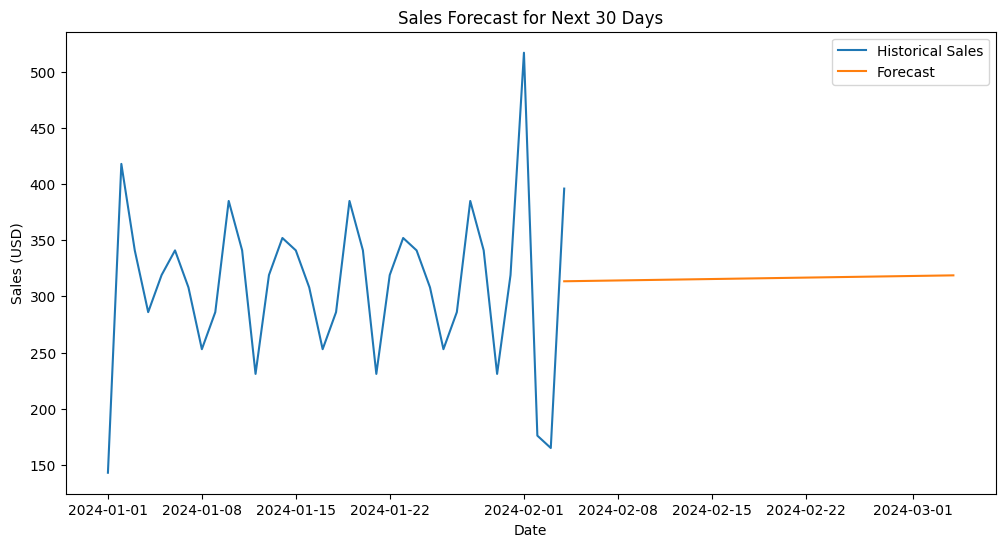

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    sales['Order Date'],
    sales['Total (USD)'],
    label='Historical Sales'
)

plt.plot(
    future_dates,
    forecast,
    label='Forecast'
)

plt.title(
    'Sales Forecast for Next 30 Days'
)

plt.xlabel('Date')

plt.ylabel('Sales (USD)')

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(X)

mae = mean_absolute_error(
    y,
    pred
)

print("MAE =", mae)

MAE = 54.80715428571428
